# **투자자 위험 감수 및 로보 어드바이저**

## 1. 문제 정의
- 예측되는 변수: 개인의 '참' 위험 허용 범위
- 예측 변수: 개인의 인구통계적, 재정적, 행동적 속성

## 2. 데이터 불러오기

In [1]:
import pandas as pd
dataset = pd.read_excel('/Users/shardone/Desktop/SW/금융 전략을 위한 머신러닝/SCFP2009panel.xlsx')
dataset.shape

(19285, 515)

## 3. 데이터 준비 및 특성 선택

### 예측되는 변수 준비
- 위험 자산: 뮤추얼 펀드, 주식, 채권에 대한 투자
- 비위험 자산: 예금/저축 잔고, 예금 증서, 기타 현금 잔고 및 등기물

In [3]:
# 2007년의 위험 자산과 무위험 자산 계산
dataset['RiskFree07'] = dataset['LIQ07'] + dataset['CDS07'] + dataset['SAVBND07'] \
    + dataset['CASHLI07']
dataset['Risky07'] = dataset['NMMF07'] + dataset['STOCKS07'] + dataset['BOND07']

# 2009년의 위험 자산과 무위험 자산 계산
dataset['RiskFree09'] = dataset['LIQ09'] + dataset['CDS09'] + dataset['SAVBND09'] \
    + dataset['CASHLI09']
dataset['Risky09'] = dataset['NMMF09'] + dataset['STOCKS09'] + dataset['BOND09']

# 2007년의 위험 허용 범위 계산
dataset['RT07'] = dataset['Risky07'] / (dataset['Risky07'] + dataset['RiskFree07'])

# 2009년 위험 자산 정규화를 위한 평균주가지수
Average_SP500_2007 = 1478
Average_SP500_2009 = 948

# 2009년의 위험 허용 범위 계산
dataset['RT09'] = dataset['Risky09'] / (dataset['Risky09'] + dataset['RiskFree09']) * \
    (Average_SP500_2009 / Average_SP500_2007)

# 데이터 확인
dataset.head()


,YY1,Y1,WGT09,AGE07,AGECL07,EDUC07,EDCL07,MARRIED07,KIDS07,LIFECL07,...,TRANSFOTHINCPCT,PSAVINGPCT,LEVERAGEPCT,I,RiskFree07,Risky07,RiskFree09,Risky09,RT07,RT09
0,1,11,11668.134198,47,3,12,2,1,0,2,...,0.0,93.125197,270.403054,57,7994.813847,0.0,16000,17000,0.0,0.330422
1,1,12,11823.456494,47,3,12,2,1,0,2,...,0.0,93.125197,249.593620,57,7994.813847,0.0,19000,18000,0.0,0.312036
2,1,13,11913.228354,47,3,12,2,1,0,2,...,0.0,93.125197,209.233358,57,7984.457871,0.0,13000,12000,0.0,0.307876
3,1,14,11929.394266,47,3,12,2,1,0,2,...,0.0,93.125197,209.273158,57,7984.457871,0.0,25000,13000,0.0,0.219429
4,1,15,11917.722907,47,3,12,2,1,0,2,...,0.0,93.125197,232.690767,57,7994.813847,0.0,17000,12000,0.0,0.265410


In [5]:
# 2007년과 2009년 사이 위험 허용 범위 변화율 계산
import numpy as np
dataset['PercentageChange'] = np.abs(dataset['RT09'] / dataset['RT07'] - 1)

In [7]:
# NA를 포함하는 행 삭제
dataset = dataset.dropna(axis=0)
dataset = dataset[~dataset.isin([np.nan, np.inf, -np.inf]).any(axis=1)]

/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_30345/1746057282.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['RT07'], hist=True, kde=False, bins=int(180/5),


<Axes: xlabel='RT07'>

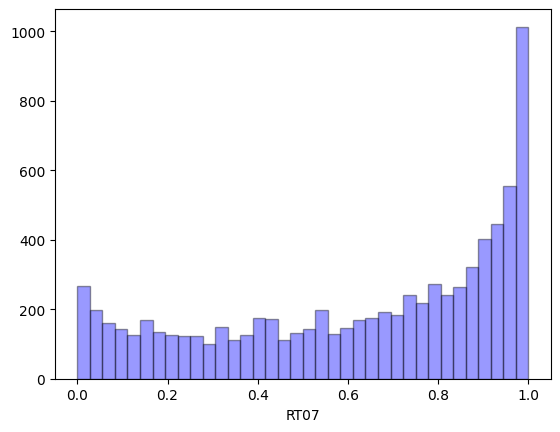

In [10]:
# 2007년 위험 허용 범위 분포
import seaborn as sns
sns.distplot(dataset['RT07'], hist=True, kde=False, bins=int(180/5),
             color='blue', hist_kws={'edgecolor': 'black'})

/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_30345/3070005276.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['RT09'], hist=True, kde=False, bins=int(180/5),


<Axes: xlabel='RT09'>

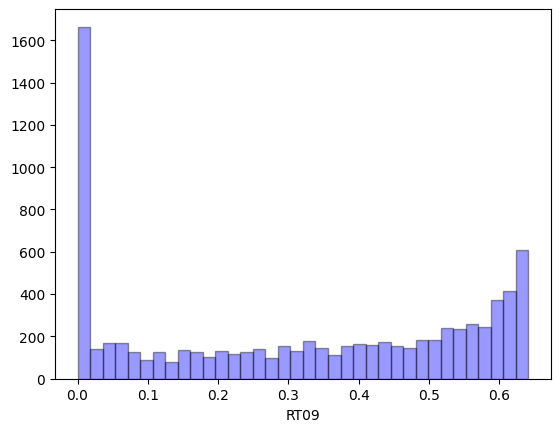

In [11]:
# 2009년 위험 허용 범위 분포
sns.distplot(dataset['RT09'], hist=True, kde=False, bins=int(180/5),
             color='blue', hist_kws={'edgecolor': 'black'})

In [12]:
# 위험 허용 범위 변화가 10% 미만인 지능형 투자자 선택
dataset3 = dataset[dataset['PercentageChange'] <= .1]

# 참 위험 허용 범위 계산
dataset3['TrueRiskTolerance'] = (dataset3['RT07'] + dataset3['RT09']) / 2

# 불필요한 변수 제거
dataset3.drop(labels=['RT07', 'RT09'], axis=1, inplace=True)
dataset3.drop(labels=['PercentageChange'], axis=1, inplace=True)

/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_30345/148424943.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset3['TrueRiskTolerance'] = (dataset3['RT07'] + dataset3['RT09']) / 2
/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_30345/148424943.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset3.drop(labels=['RT07', 'RT09'], axis=1, inplace=True)
/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_30345/148424943.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the

### 특성 선택 - 특성 공간 제한
**사용할 특성**
- 인구 통계적 속성: 연령, 학력, 결혼 상태, 자녀 수, 직업
- 재무 속성: 지출 대 소득, 순자산, 소득
- 행동 속성: 위험을 감수하려는 의지

In [13]:
keep_list2 = ['AGE07', 'EDCL07', 'MARRIED07', 'KIDS07', 'OCCAT107',
              'INCOME07', 'RISK07', 'NETWORTH07', 'TrueRiskTolerance']

drop_list2 = [col for col in dataset3.columns if col not in keep_list2]
dataset3.drop(labels=drop_list2, axis=1, inplace=True)

/var/folders/8p/g5q_r1c51x7_mgkd5kmh4s3m0000gn/T/ipykernel_30345/900090804.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset3.drop(labels=drop_list2, axis=1, inplace=True)


**상관관계**

<Axes: title={'center': 'Correlation Matrix'}>

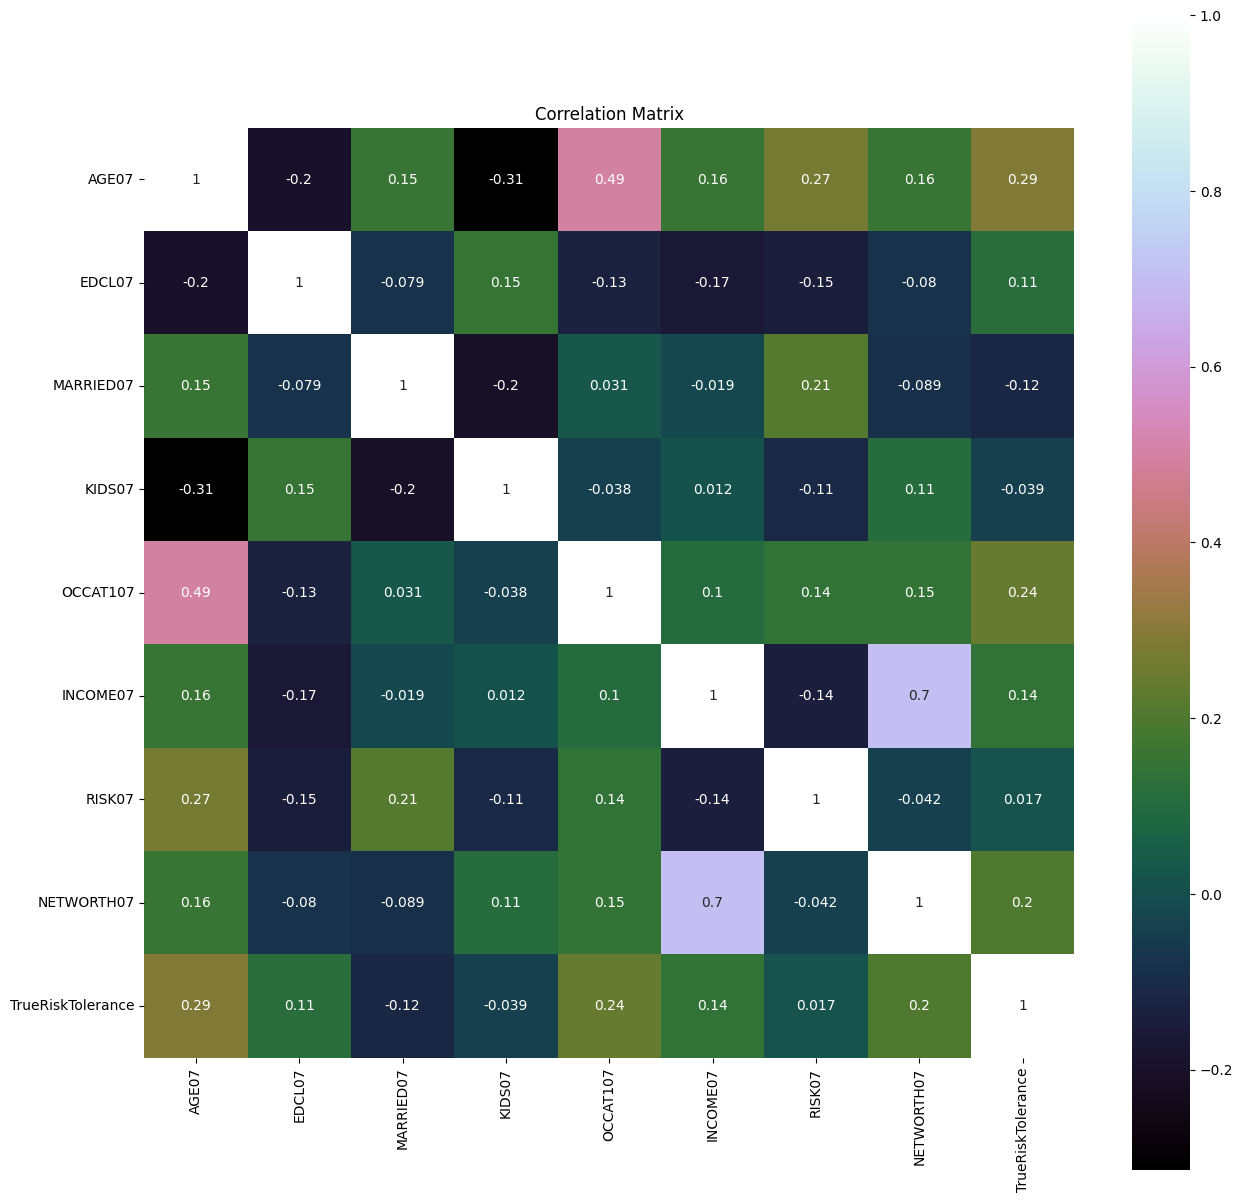

In [16]:
# 상관관계
from matplotlib import pyplot
correlation = dataset3.corr()
pyplot.figure(figsize=(15,15))
pyplot.title('Correlation Matrix')
sns.heatmap(correlation, vmax=1, square=True, annot=True, cmap='cubehelix')

## 4. 모델 평가

**훈련 - 테스트 분할**

In [18]:
from sklearn.model_selection import train_test_split
Y = dataset3["TrueRiskTolerance"]
X = dataset3.loc[:, dataset3.columns != 'TrueRiskTolerance']

validation_size = 0.2
seed = 3

X_train, X_validation, Y_train, Y_validation = \
    train_test_split(X, Y, test_size=validation_size, random_state=seed)

**테스트 옵현 및 평가 메트릭**

In [19]:
num_folds = 10
scoring = 'r2'

**모델 및 알고리즘 비교**

In [22]:
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor)

# 알고리즘 체크
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('EN', ElasticNet()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVR', SVR()))

# 부스팅 방법
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))

# 배깅 방법
models.append(('RFR', RandomForestRegressor()))
models.append(('ETR', ExtraTreesRegressor()))

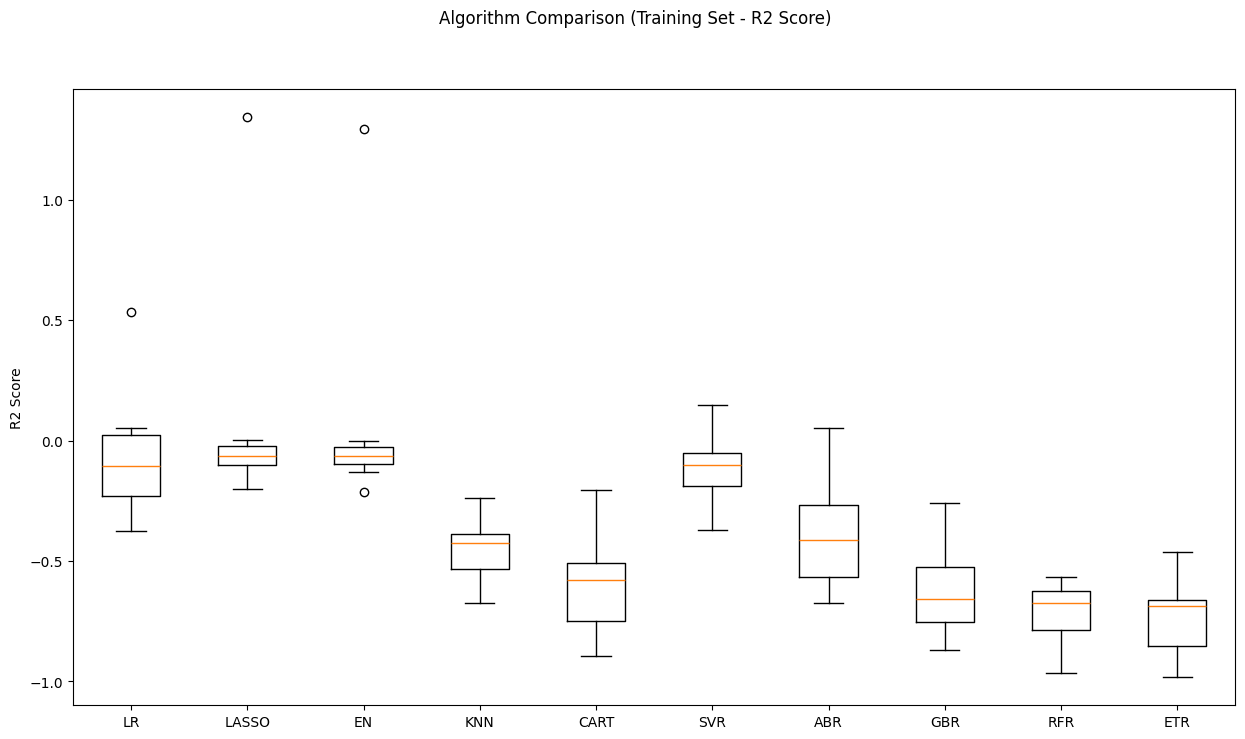

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

seed = 7
names = []
kfold_results = []
train_results = []
validation_results = []

for name, model in models:
    names.append(name)
    
    # K-Fold 설정
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    
    # 교차검증 (R2 사용, 높을수록 좋음)
    cv_results = -1*cross_val_score(model, X_train, Y_train,
                                 cv=kfold, scoring=scoring)
    kfold_results.append(cv_results)
    
    # 모델 학습
    model.fit(X_train, Y_train)
    
    # 훈련 성능 (R2)
    train_pred = model.predict(X_train)
    train_r2 = r2_score(Y_train, train_pred)
    train_results.append(train_r2)
    
    # 검증 성능 (R2)
    val_pred = model.predict(X_validation)
    val_r2 = r2_score(Y_validation, val_pred)
    validation_results.append(val_r2)

# ==========================
# 📊 시각화
# ==========================

fig = plt.figure(figsize=(15,8))
fig.suptitle('Algorithm Comparison (Training Set - R2 Score)')

ax = fig.add_subplot(111)
plt.boxplot(kfold_results)
ax.set_xticklabels(names)
plt.ylabel("R2 Score")
plt.show()

## 5. 모델 튜닝 및 격자 탐색

In [29]:
# 격자 탐색: RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50,100,150,200,250,300,350,400]}

model = RandomForestRegressor()
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

grid = GridSearchCV(estimator=model,
                    param_grid=param_grid,
                    scoring=scoring,
                    cv=kfold)

grid_result = grid.fit(X_train, Y_train)

print("Best: %f using %s" % (grid_result.best_score_,
                             grid_result.best_params_))

means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']

Best: 0.742136 using {'n_estimators': 250}


격자 탐색 후 예측기 수가 250개인 랜덤 포레스트가 가장 좋은 모델임을 알 수 있다.

## 6. 모델 확정

### 테스트 데이터셋의 결과

In [30]:
model = RandomForestRegressor(n_estimators=250)
model.fit(X_train, Y_train)

RandomForestRegressor(n_estimators=250)

  **훈련셋의 성능**

In [34]:
from sklearn.metrics import r2_score

predictions_train = model.predict(X_train)
print(r2_score(Y_train, predictions_train))

0.9623186198467175


**테스트셋의 성능**

In [33]:
from sklearn.metrics import mean_squared_error
predictions = model.predict(X_validation)

print(mean_squared_error(Y_validation, predictions))
print(r2_score(Y_validation, predictions))

0.0074390268937956725
0.7719583389364103


### 특성의 중요성 및 직관성

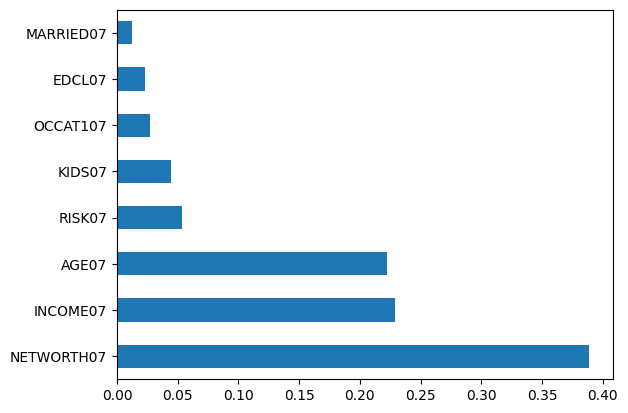

In [36]:
model = RandomForestRegressor(n_estimators=200, n_jobs=-1)
model.fit(X_train, Y_train)

feat_importances = pd.Series(model.feature_importances_,
                             index=X.columns)

feat_importances.nlargest(10).plot(kind='barh')
plt.show()

### 추후 사용을 위한 모델 저장

In [37]:
# Pickle을 사용한 모델 저장
from pickle import dump
from pickle import load

filename = 'finalized_model.sav'
dump(model, open(filename, 'wb'))

In [38]:
# 디스크로부터 모델 불러오기
loaded_model = load(open(filename, 'rb'))

predictions = loaded_model.predict(X_validation)

result = mean_squared_error(Y_validation, predictions)
print(r2_score(Y_validation, predictions))
print(result)

0.7647727877731934
0.007673429274924664
